# Stage 06 — Classification (RQ2)

**Owner:** Sandesh Shahi (Analysis Lead)

**Research question.** *Can organisations be classified as high vs low proportion of women in management based on their policy and structural characteristics?*

**Models.** Random Forest (primary) + Gaussian Naive Bayes (baseline), as justified in Assessment 1 §4.3 — RF handles mixed feature types and exposes feature importances; NB is the lightweight baseline whose feature-independence assumption is known to be violated, motivating the comparison.

**Evaluation.** Accuracy, precision, recall, F1, ROC-AUC, confusion matrix. The median split guarantees balanced classes, so accuracy is meaningful.

**Inputs.** Checkpoints from notebook 03.

**Outputs.**
- `data/processed/checkpoints/06_rf_model.pkl`, `06_nb_model.pkl`
- `data/processed/checkpoints/06_cls_metrics.json`
- `outputs/figures/rq2_*.png`
- `outputs/tables/rq2_feature_importance.csv`

## 1. Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config, classification, evaluation, visualisation, reporting
from src.utils import save_checkpoint

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X = _load("03_X.parquet")
y_cls = _load("03_y_cls.parquet").iloc[:, 0]

# Drop any NA targets
mask = y_cls.notna()
X_cls = X.loc[mask].reset_index(drop=True)
y_cls_clean = y_cls.loc[mask].astype(int).reset_index(drop=True)

print("X_cls:", X_cls.shape)
print("Class balance:")
print(y_cls_clean.value_counts())

X_cls: (7971, 24)
Class balance:
women_mgmt_high
0    4010
1    3961
Name: count, dtype: int64


## 2. Fit Random Forest (primary model)

In [2]:
rf_res = classification.fit_random_forest(X_cls, y_cls_clean)
rf_metrics = evaluation.classification_metrics(
    rf_res.y_test.values, rf_res.y_pred_test, rf_res.y_proba_test
)
print("Random Forest — test-set metrics")
for k, v in rf_metrics.items():
    print(f"  {k:10s} = {v:.4f}")

21:45:47 | INFO    | src.classification | RF fitted: 6376 train / 1595 test; class balance=0.50
Random Forest — test-set metrics
  Accuracy   = 0.7674
  Precision  = 0.7972
  Recall     = 0.7137
  F1         = 0.7532
  ROC_AUC    = 0.8598


## 3. Fit Naive Bayes (baseline)

In [3]:
nb_res = classification.fit_naive_bayes(X_cls, y_cls_clean)
nb_metrics = evaluation.classification_metrics(
    nb_res.y_test.values, nb_res.y_pred_test, nb_res.y_proba_test
)
print("Naive Bayes — test-set metrics")
for k, v in nb_metrics.items():
    print(f"  {k:10s} = {v:.4f}")

21:45:47 | INFO    | src.classification | NB fitted: 6376 train / 1595 test
Naive Bayes — test-set metrics
  Accuracy   = 0.7524
  Precision  = 0.6925
  Recall     = 0.9029
  F1         = 0.7838
  ROC_AUC    = 0.8533


## 4. Side-by-side comparison

In [4]:
comp = pd.DataFrame({"RandomForest": rf_metrics, "NaiveBayes": nb_metrics}).round(4)
comp["RF − NB"] = (comp["RandomForest"] - comp["NaiveBayes"]).round(4)
comp

,RandomForest,NaiveBayes,RF − NB
Accuracy,0.7674,0.7524,0.0150
Precision,0.7972,0.6925,0.1047
Recall,0.7137,0.9029,-0.1892
F1,0.7532,0.7838,-0.0306
ROC_AUC,0.8598,0.8533,0.0065


## 5. Confusion matrix (Random Forest)

Confusion matrix (rows = actual, cols = predicted):
             Pred Low  Pred High
Actual Low        658        144
Actual High       227        566
21:45:47 | INFO    | src.visualisation | Saved rq2_confusion_matrix.png


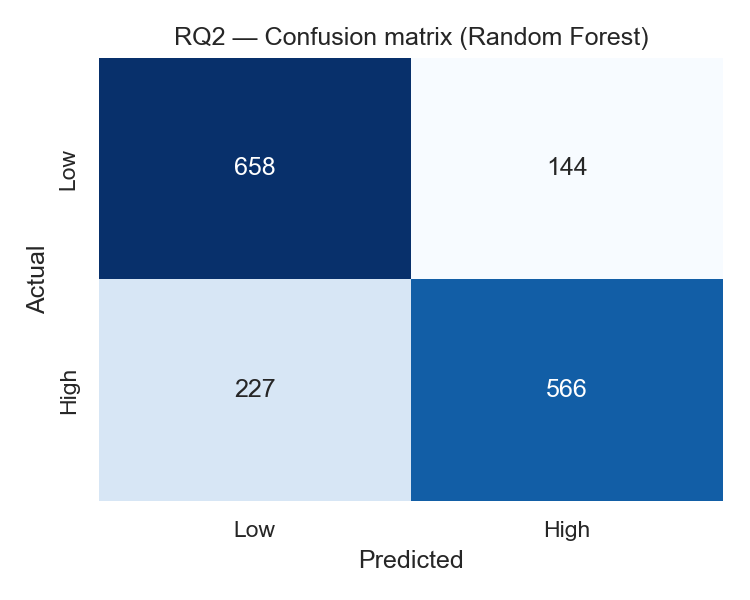

In [5]:
cm = evaluation.confusion(rf_res.y_test.values, rf_res.y_pred_test)
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm, index=["Actual Low", "Actual High"],
                   columns=["Pred Low", "Pred High"]))
p = visualisation.plot_confusion_matrix(cm)
display(Image(str(p)))

## 6. Feature importance — what drives the classification?

Random Forest's Gini-based feature importance ranks which predictors most reduce impurity across trees. The top features are the ones we should talk about on the slides.

21:45:47 | INFO    | src.visualisation | Saved rq2_feature_importance.png


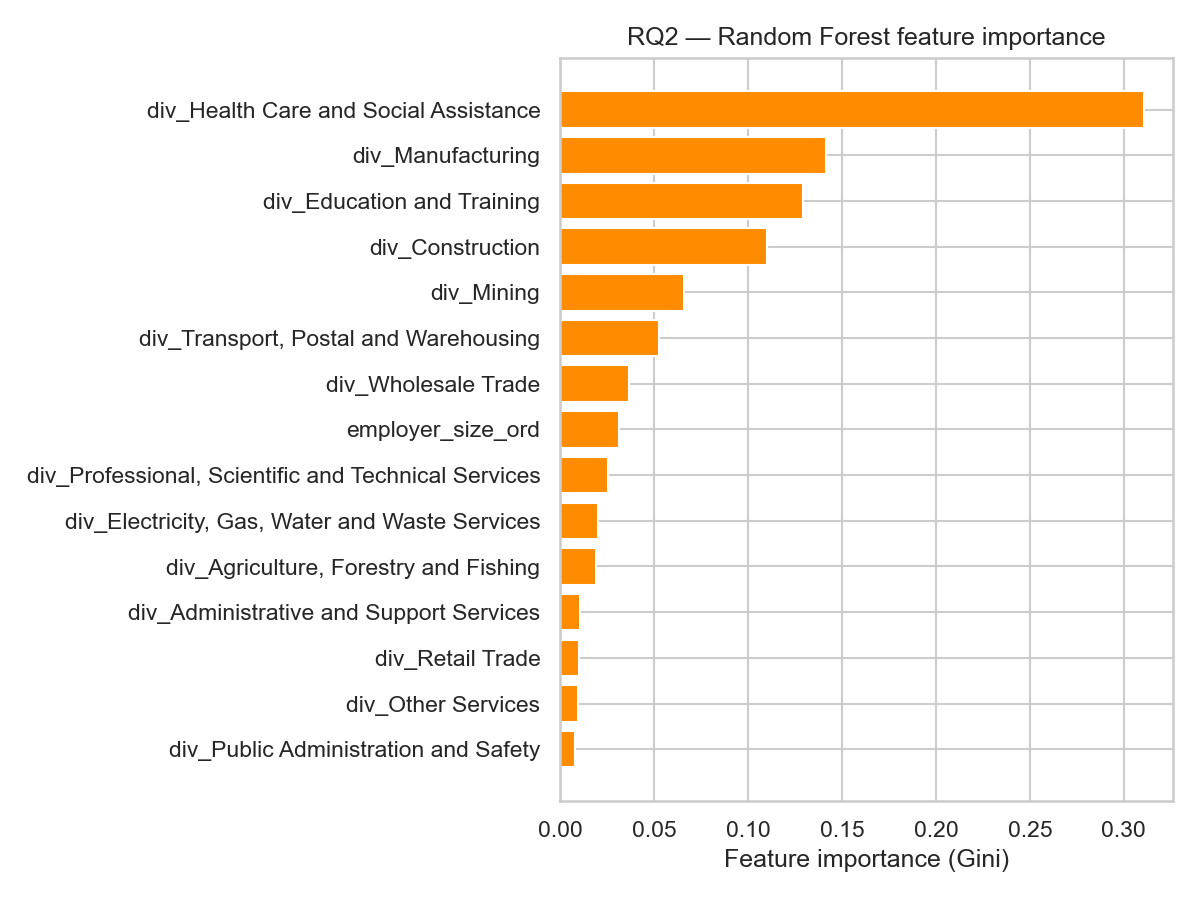

,feature,importance
0,div_Health Care and Social Assistance,0.310674
1,div_Manufacturing,0.141313
2,div_Education and Training,0.129433
3,div_Construction,0.109858
4,div_Mining,0.065909
5,"div_Transport, Postal and Warehousing",0.052795
6,div_Wholesale Trade,0.036704
7,employer_size_ord,0.031205
8,"div_Professional, Scientific and Technical Ser...",0.025684
9,"div_Electricity, Gas, Water and Waste Services",0.020400


In [6]:
importances = classification.feature_importance(rf_res, top_n=15)
reporting.write_feature_importance(importances)
p = visualisation.plot_feature_importance(importances)
display(Image(str(p)))
importances

## 7. Checkpoint

In [7]:
save_checkpoint(rf_res.model, config.CHECKPOINT_DIR / "06_rf_model.pkl")
save_checkpoint(nb_res.model, config.CHECKPOINT_DIR / "06_nb_model.pkl")
with open(config.CHECKPOINT_DIR / "06_cls_metrics.json", "w") as f:
    json.dump({"random_forest": rf_metrics, "naive_bayes": nb_metrics}, f, indent=2)
print("Saved models + metrics.")

Saved models + metrics.


## Takeaways for the slide deck

- Primary headline: RF vs NB accuracy/F1 gap.
- The top-5 features from the importance chart become the practical drivers story (e.g. "employers offering X are much more likely to have a High share of women in management").
- Whether the RF lift over NB is *statistically significant* is tested in notebook 07.

**Next:** `07_statistical_tests.ipynb` — paired-CV t-tests for both model pairs.